In [1]:
!ls -l  # check that we are in the correct directory

total 25
drwxr-x--- 1 root users    0 Jan  1  1970 adaptations
drwxr-xr-x 1 root users    0 Oct 11 11:11 animations
drwxr-x--- 1 root users    0 Jan  1  1970 base_classes
drwxr-x--- 1 root users    0 Jan  1  1970 components
drwxr-x--- 1 root users    0 Jan  1  1970 configs
-rw-r----- 1 root users  290 Oct 11 11:07 helpers.py
drwxr-x--- 1 root users    0 Jan  1  1970 logs
-rw-r----- 1 root users 2457 Nov 22 08:50 main.py
-rw-r----- 1 root users 2696 Nov 22 08:50 plots.py
drwxr-x--- 1 root users    0 Jan  1  1970 prompt_templates
drwxr-xr-x 1 root users    0 Oct 11 10:55 __pycache__
-rw-r----- 1 root users  781 Oct 11 11:07 README.md
-rw-r----- 1 root users  139 Oct 21 08:59 requirements.txt
-rw-r----- 1 root users 3104 Nov 22 10:33 simulation.py
-rw-r----- 1 root users 2193 Nov 11 09:25 stats.py
-rw-r----- 1 root users 2363 Nov 22 08:50 utils.py
-rw-r----- 1 root users 8234 Nov 22 08:50 visualizer.py


In [2]:
import subprocess
import os

def run(args, repeats=10):
    print(args)
    for repeat in range(repeats):
        print(f"  Run #{repeat}")
        run = ["python", "main.py", *args, "-s", str(repeat + 1), "-e", str(repeat + 1)]
        if repeat % 10 == 0:
            run.append("--animation")
        
        # disable TF errors
        env = dict(os.environ, TF_CPP_MIN_LOG_LEVEL="3")

        result = subprocess.run(run, capture_output=True, env=env)
        stdout = result.stdout.decode("utf-8")
        stderr = result.stderr.decode("utf-8")

        damage = stdout.partition("damage: ")[2].partition("\n")[0]
        print(f"    Damage: {damage}")

        #print(stdout.partition("Simulation done\n")[2])
        # print(stdout)
        if stderr:
            print(stderr)

In [3]:
grid_params = {
    "birdCohesion": [0, 0.25, 0.5, 0.75, 1],
    "bird.WaitBeforeEat": [0, 1, 2, 3, 5, 8],
    "bird.NearbyBirdsToEat": [0, 1, 2],
}

In [8]:
# generate config files

for param in grid_params:
    for value in grid_params[param]:
        with open(f"../configs/grid_search_birds/{param}_{value}.yaml", "w") as f:
            f.write(f"log_dir.append: {param}_{value},\n")
            if "." in param:
                first, second = param.split(".")
                f.write(f"{first}:\n")
                f.write(f"  {second}: {value}\n")
            else:
                f.write(f"{param}: {value}\n")

In [5]:
import itertools

grid = list(itertools.product(*grid_params.values()))
print(len(grid))

90


In [6]:
adaptations = ["rule_based_random", "rule_based_full_nearest", "rule_based_full_nearest_oracle"]

In [9]:
for i, params in enumerate(grid, start=1):
    print(f"{i}/{len(grid)}")
    for adaptation in adaptations:
        args = ["configs/config_no_battery.yaml", "../configs/grid_search_birds/grid_search_birds.yaml"]

        for param, value in zip(grid_params, params):
            args.append(f"../configs/grid_search_birds/{param}_{value}.yaml")

        args.append(f"configs/{adaptation}.yaml")

        run(args)

  Run #1
    Damage: 4
  Run #2
    Damage: 2
  Run #3
    Damage: 1
  Run #4
    Damage: 0
  Run #5
    Damage: 3
  Run #6
    Damage: 2
  Run #7
    Damage: 0
  Run #8
    Damage: 4
  Run #9
    Damage: 3
['configs/config_no_battery.yaml', '../configs/grid_search_birds/grid_search_birds.yaml', '../configs/grid_search_birds/birdCohesion_1.yaml', '../configs/grid_search_birds/bird.WaitBeforeEat_0.yaml', '../configs/grid_search_birds/bird.NearbyBirdsToEat_2.yaml', 'configs/rule_based_full_nearest_oracle.yaml']
  Run #0
    Damage: 4
  Run #1
    Damage: 2
  Run #2
    Damage: 5
  Run #3
    Damage: 0
  Run #4
    Damage: 2
  Run #5
    Damage: 5
  Run #6
    Damage: 1
  Run #7
    Damage: 1
  Run #8
    Damage: 2
  Run #9
    Damage: 1
76/90
['configs/config_no_battery.yaml', '../configs/grid_search_birds/grid_search_birds.yaml', '../configs/grid_search_birds/birdCohesion_1.yaml', '../configs/grid_search_birds/bird.WaitBeforeEat_1.yaml', '../configs/grid_search_birds/bird.NearbyBirdsToE

In [2]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

folder = Path("../logs/grid_search_birds")

In [10]:
files = sorted(folder.glob("*/*/*.csv"))
print(len(files), "files found")

summary = pd.DataFrame(columns=["params", "adaptation", "damage"])

for file in files:
    try:
        data = pd.read_csv(file)
        damage = data.iloc[-1]["damage"]
        
        parts = list(file.parts)
        params = parts[-3].replace(",", "\n")
        adaptation = parts[-2]

        summary.loc[len(summary)] = [params, adaptation, damage]
    except pd.errors.EmptyDataError:
        print("Skipping empty file", file_name)
    except IndexError:
        print("Index error in file", file_name)

summary.to_csv(folder / "summary.csv", index=False)

2700 files found


In [3]:
summary = pd.read_csv(folder / "summary.csv")

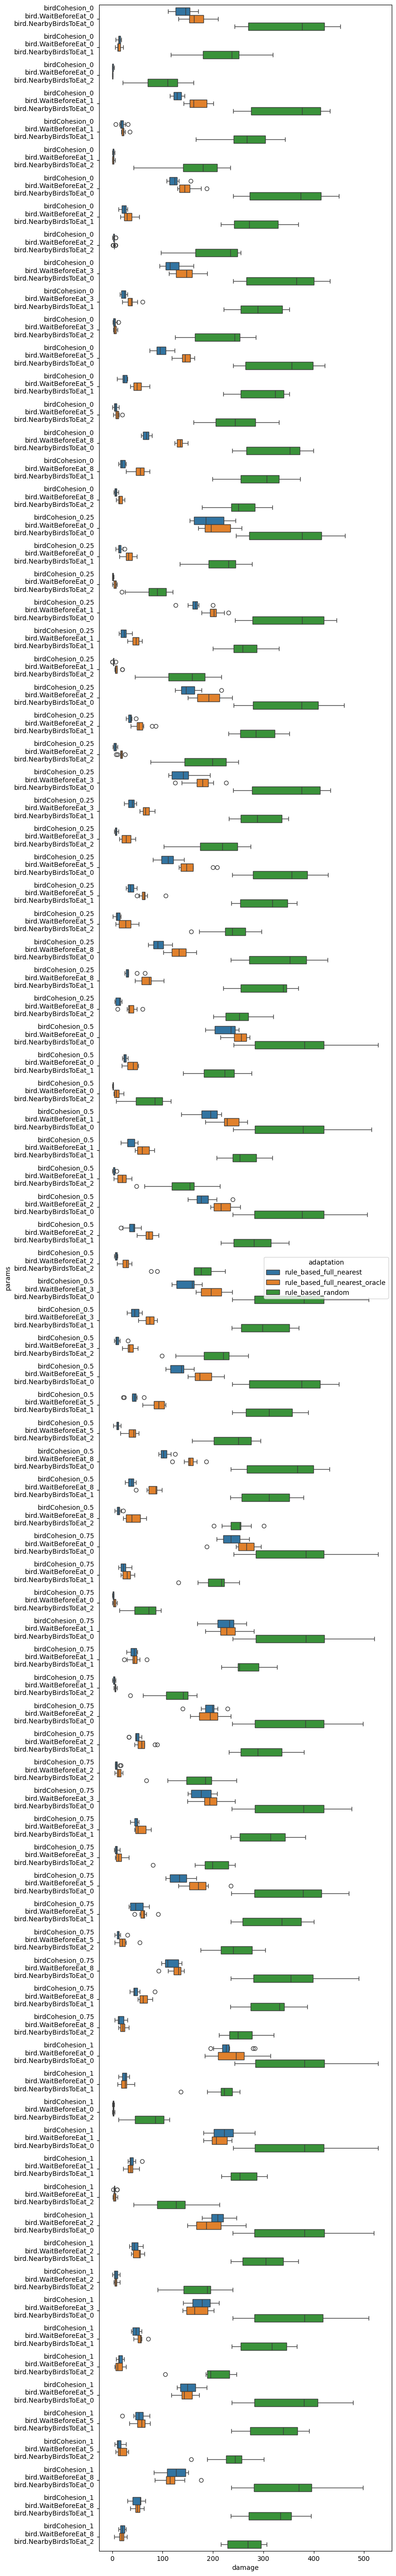

In [5]:
fig, ax = plt.subplots(figsize=(8, 70))
sns.boxplot(x="damage", y="params", hue="adaptation", data=summary, ax=ax)
plt.show()

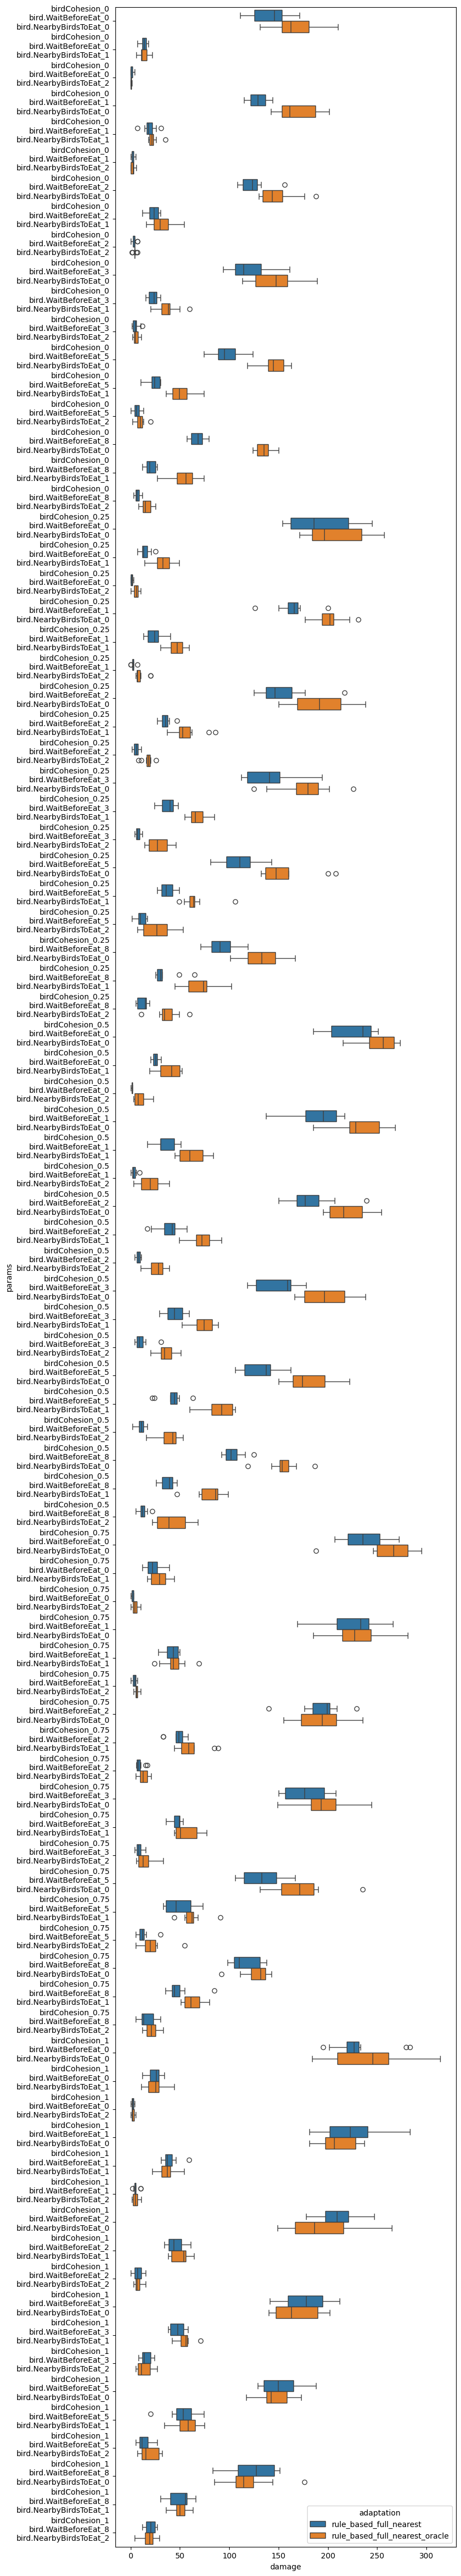

In [6]:
fig, ax = plt.subplots(figsize=(8, 60))
sns.boxplot(x="damage", y="params", hue="adaptation", data=summary[summary["adaptation"] != "rule_based_random"], ax=ax)
plt.show()

In [9]:
# split the params into columns
params = summary["params"].str.split("\n", expand=True)
del params[3]
params.columns = ["cohesion", "wait", "nearby"]
summary = pd.concat([summary, params], axis=1)

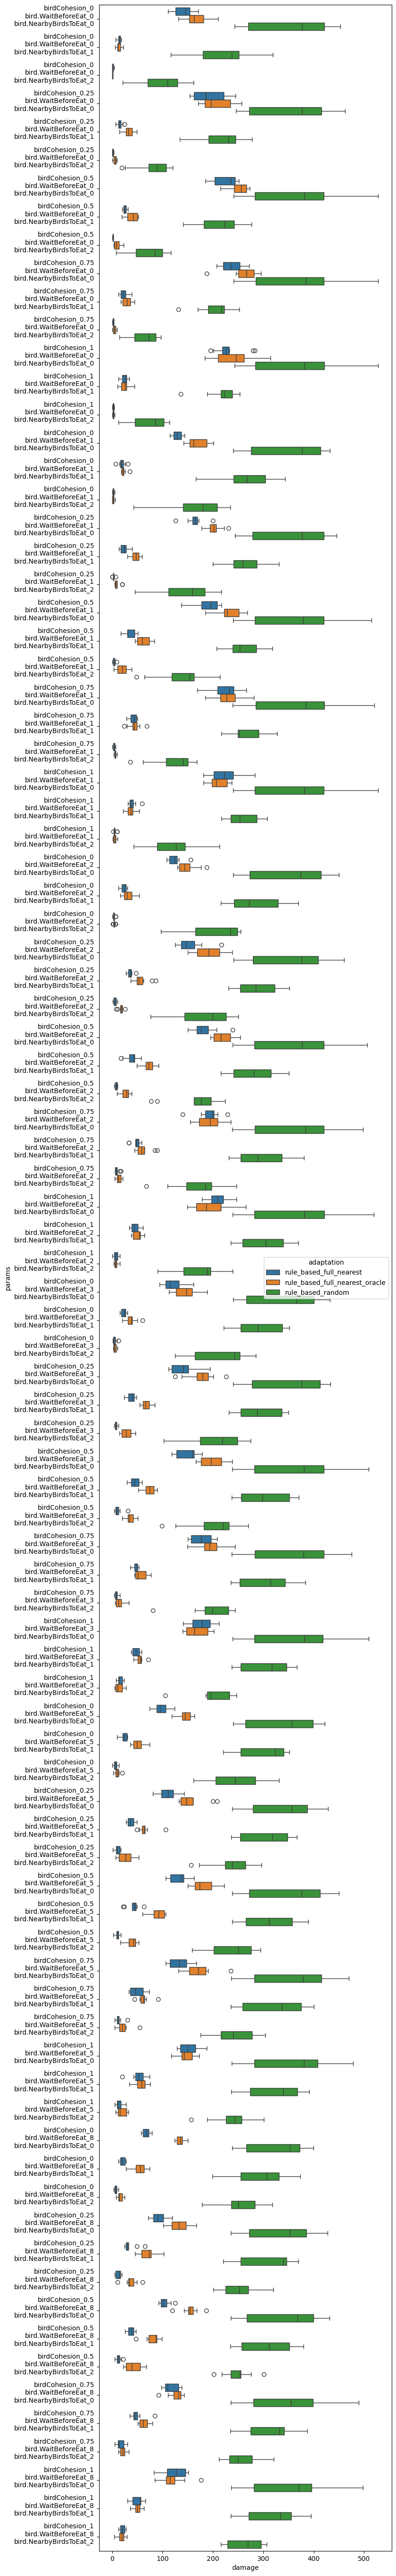

In [12]:
fig, ax = plt.subplots(figsize=(8, 70))
sns.boxplot(x="damage", y="params", hue="adaptation", data=summary.sort_values("wait", kind="stable"), ax=ax)
plt.show()

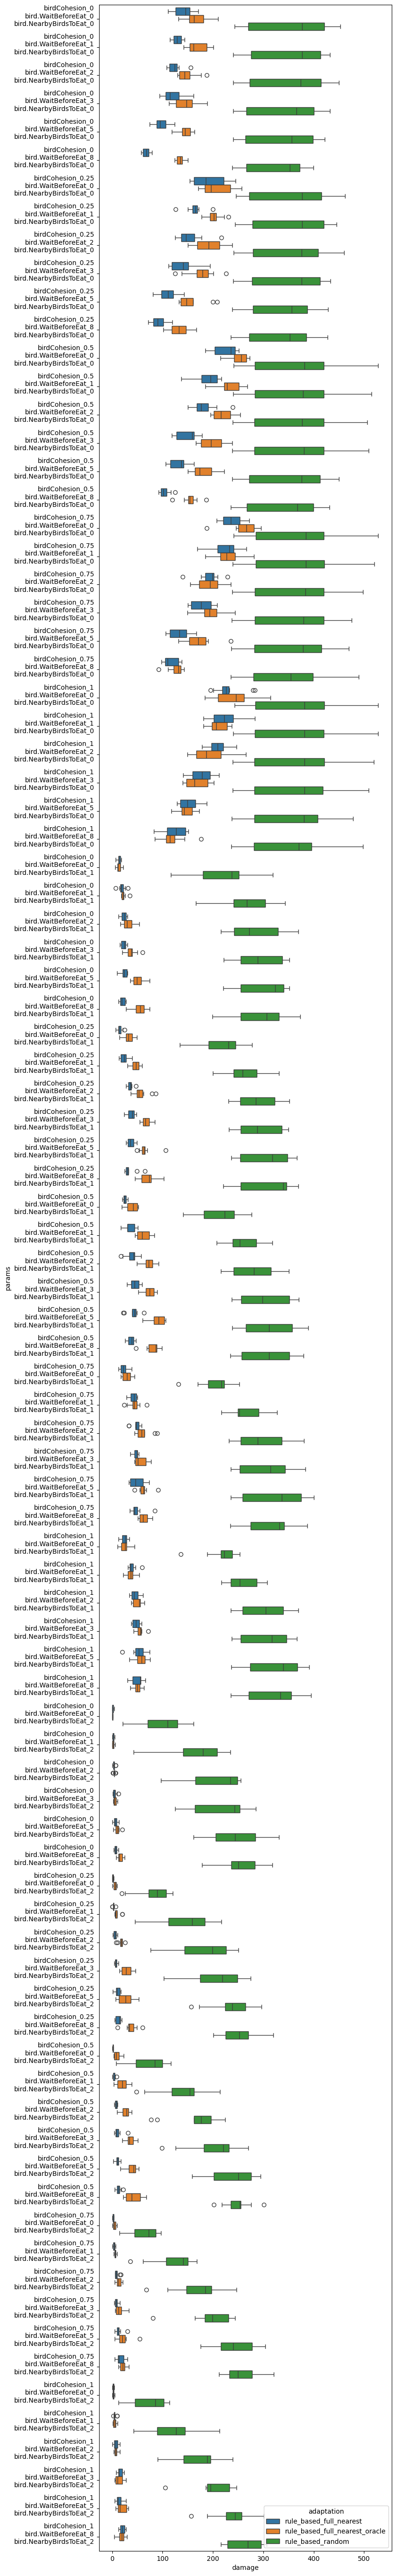

In [13]:
fig, ax = plt.subplots(figsize=(8, 70))
sns.boxplot(x="damage", y="params", hue="adaptation", data=summary.sort_values("nearby", kind="stable"), ax=ax)
plt.show()

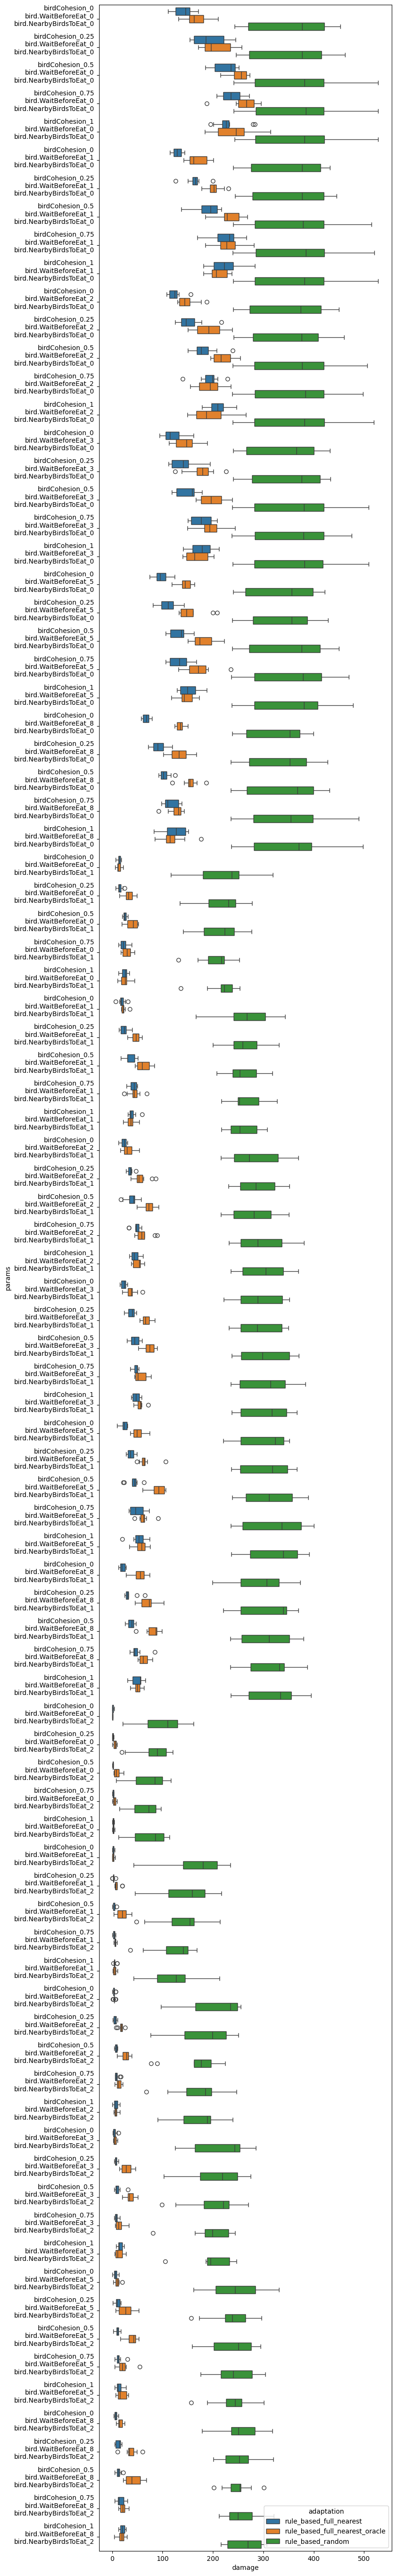

In [15]:
fig, ax = plt.subplots(figsize=(8, 70))
sns.boxplot(x="damage", y="params", hue="adaptation", data=summary.sort_values(["nearby", "wait"], kind="stable"), ax=ax)
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=6dddcb2f-9a74-4511-ab27-8e86504a138c' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>